<img src="../resources/logo.png" width="300" height="80"></img><p><h3 style="font-size:24pt; border-bottom: 0px; font-weight: bolder;">Universidad de La Salle</h3><h3 style="font-size:24pt; border-bottom: 0px; font-weight: bolder;">T&eacute;cnicas de An&aacute;lisis Estad&iacute;stico de Modelos Supervisados</h3><h3 style="font-size:24pt; border-bottom: 0px; font-weight: bolder;">Análisis de Ausentismo Laboral por causas M&eacute;dicas en Instituci&oacute;n Prestadora de Servicios de Salud (IPS)</h3><br/><h3>Daniel Mauricio Díaz Forero</h3><h3>Johan Andrey Mina Forero</h3></p>

### **1. Importar Librerías**

In [1]:
import os
import numpy as np
import pandas as pd
from lib.limpieza import LimpiezaDatos
from lib.graficas import Graficos
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

### **2. Lectura del Dataset**

In [2]:
try: 
    path_dataset = r"../data/BASE DE AUSENTISMO PARA ANALISIS.xlsx"
    if not os.path.exists(path_dataset):
        raise FileNotFoundError(f"(ERROR): No se ha encontrado el archivo del conjunto de datos.")
    df = pd.read_excel(path_dataset)    
    print("(OK): Conjuntos de datos cargado exitosamente.")
except Exception as ex:
    print(f"(ERROR): No se ha podido leer el archivo del conjunto de datos. {str(ex)}")

(OK): Conjuntos de datos cargado exitosamente.


### **3. Limpieza del Dataset**

In [3]:
clean = LimpiezaDatos(df)       
df = clean.getDataFrame() # Ejecutar todas las operaciones de limpieza sobre el Conjunto de Datos
df.isnull().sum()

periodo              0
mes_evento           0
cargo                0
dependencia          0
tipo_evento          0
dias_incapacidad     0
prorroga             0
codigo_cie10         0
salario_base         0
valor_salario        0
valor_incapacidad    0
dtype: int64

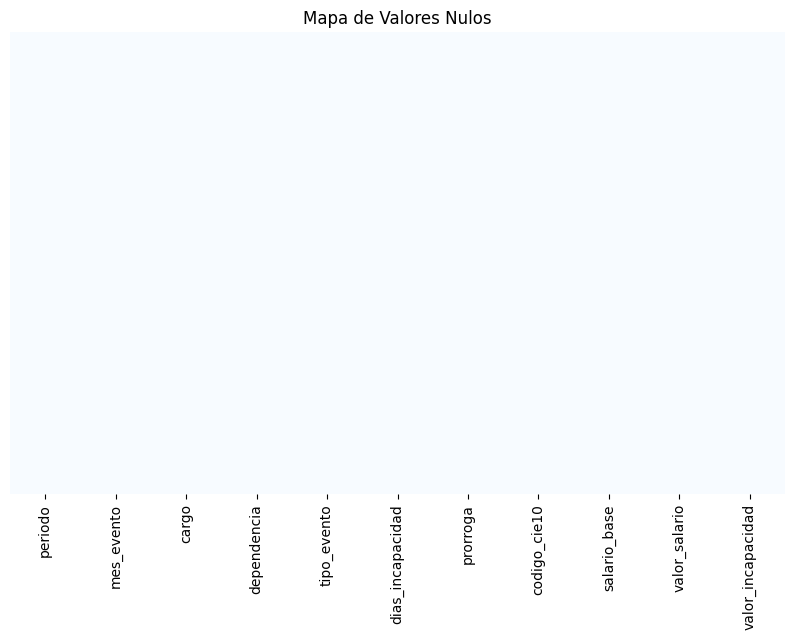

In [4]:
graph = Graficos(df)
graph.heatMapValoresNulos()

In [5]:
# Identificar tipos de variables
cuantitativas = df.select_dtypes(include=[np.number]).columns.tolist()
cualitativas = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Variables cuantitativas:", cuantitativas)
print("Variables cualitativas:", cualitativas)

Variables cuantitativas: ['periodo', 'mes_evento', 'dias_incapacidad', 'prorroga', 'salario_base', 'valor_salario', 'valor_incapacidad']
Variables cualitativas: ['cargo', 'dependencia', 'tipo_evento', 'codigo_cie10']


### **4. Análisis Exploratorio de Datos (EDA)**

##### 4.1 Variables Cuantitativas

In [6]:
df["periodo"] = df["periodo"].replace(1934, 2024) # Hay valores con el periodo "equivocado". Luego de revisar la fecha de inicio de incapacidad 
                                                  # y de fin de incapacidad, se imputa el valor "1934" a 2024, por presunto error de digitacion.
df["periodo"].value_counts().sort_index()                                                  

periodo
2022    174
2023    239
2024    249
2025    288
Name: count, dtype: Int64

In [7]:
df["mes_evento"].value_counts().sort_index()

mes_evento
1      65
2      71
3      86
4      89
5      76
6      80
7      86
8      86
9     103
10     95
11     64
12     49
Name: count, dtype: int64

In [8]:
df["dias_incapacidad"].value_counts().sort_index()

dias_incapacidad
1      112
2      436
3      178
4       43
5       40
6        6
7       21
8       21
10      15
11       1
13       3
14       4
15       8
17       1
19       1
20       3
21       1
22       3
23       1
24       1
28       2
30      41
31       7
126      1
Name: count, dtype: Int64

In [9]:
df["prorroga"].value_counts().sort_index()

prorroga
0    913
1     37
Name: count, dtype: int64

In [10]:
df["salario_base"].value_counts().sort_index()

salario_base
750000.0       3
870000.0       6
1000000.0     27
1002518.0     54
1005000.0      1
1010186.0      2
1011042.0      1
1014000.0      3
1044509.0      1
1045500.0      1
1060700.0      1
1062430.0      1
1079513.0      4
1086820.0      1
1087177.0      1
1088028.0      1
1093000.0      1
1093656.0      1
1104724.0      1
1123632.0      1
1155144.0      4
1159275.0      1
1160000.0    100
1165585.0      7
1171887.0      1
1179050.0      5
1190794.0      1
1190795.0     10
1200000.0      2
1231730.0      1
1234912.0     31
1254435.0      2
1255000.0      1
1268000.0      3
1274500.0      1
1274892.0      6
1297937.0      3
1300000.0    108
1303361.0      8
1304834.0      2
1314000.0      2
1316845.0      4
1322897.0      6
1331000.0      7
1338248.0      2
1338273.0      1
1338274.0      2
1347479.0      1
1375732.0      1
1378991.0      3
1378992.0      9
1382391.0      2
1391596.0      2
1410504.0      2
1413904.0      6
1423500.0    127
1435463.0      1
1439000.0      3
1

In [11]:
df["valor_salario"].value_counts().sort_index()

valor_salario
25000.00       3
29000.00       6
33333.33      27
33417.27      54
33500.00       1
33672.87       2
33701.40       1
33800.00       3
34816.97       1
34850.00       1
35356.67       1
35414.33       1
35983.77       4
36227.33       1
36239.23       1
36267.60       1
36433.33       1
36455.20       1
36824.13       1
37454.40       1
38504.80       4
38642.50       1
38666.67     100
38852.83       7
39062.90       1
39301.67       5
39693.13       1
39693.17      10
40000.00       2
41057.67       1
41163.73      31
41814.50       2
41833.33       1
42266.67       3
42483.33       1
42496.40       6
43264.57       3
43333.33     108
43445.37       8
43494.47       2
43800.00       2
43894.83       4
44096.57       6
44366.67       7
44608.27       2
44609.10       1
44609.13       2
44915.97       1
45857.73       1
45966.37       3
45966.40       9
46079.70       2
46386.53       2
47016.80       2
47130.13       6
47450.00     127
47848.77       1
47966.67       3


In [12]:
df["valor_incapacidad"].value_counts().sort_index()

valor_incapacidad
29000.00       2
33333.33       4
33417.27       5
33672.87       1
33701.40       1
35983.77       1
38666.67      17
39693.17       2
42266.67       1
43333.33      11
43800.00       1
44096.57       2
44366.67       3
46079.70       1
47130.13       2
47450.00      13
48319.33       1
49117.63       5
49226.77       2
50059.40       1
50378.13       1
51218.50       5
51667.93       2
53739.50       3
54369.73       3
57970.47       1
58000.00       4
59256.67       1
60071.30       1
63025.20       1
63823.50       3
63823.53       2
64000.00       3
65126.07       3
66666.67      13
66834.53      20
67000.00       1
67345.73       1
67600.00       1
68025.20       4
69700.00       1
70828.67       1
71967.53       3
72226.90       1
72910.40       1
74908.80       1
77009.60       2
77333.33      46
77705.67       2
77731.10       2
78125.80       1
79386.33       5
80000.00       2
82327.47      12
83629.00       1
83666.67       1
84533.33       1
84966.67     

##### 4.2 Variables Cualitativas

In [13]:
# La variable "cargo" contiene información mas de tipo "texto" que de categorías de cargos. Deben estandarizarse las categorías de esta variable !!!
df["cargo"].value_counts().sort_values() # Se puede ver que hay dos valores de "TERAPEUTA ACOMPAÑANTE" distintos ? 
                                         # "TERAPEUTA ACOMPAÑANTE" y "TERAPEUTA OCUPACIONAL" es lo mismo ? 
                                         # !!! SE DEBEN UNIFICAR LAS CATEGORIAS !!!

cargo
TECNICO EN SISTEMAS                                1
COORDINADORA SGSST                                 1
PSICOL COOTERAPEUTA                                1
TERAPUETA NEUROSENSORIAL                           1
COORD. TER.COGNIT MUSICAL                          1
FONOAUDIOLOGO                                      1
NEUROSENSORIAL - TERAPEUTA OCUPACIONAL             1
AUXILIAR ADMINISTRATIVO DE COMPRAS                 1
ACOMPAÑAMIENTO TERAPEUTICO                         1
ARCHIVO DIGITAL Y SOPORTE TEC                      1
TERAPIA OCUPACIONAL                                1
COORD. GESTIÓN HUMANA (SELECCIÓN Y BIENESTAR)      1
ANALISTA DE CONTRATACION                           1
COORDINADORA SEDE CALERA                           1
COORDINADORA DE CALIDAD                            1
COORDINADORA TALLER MUSICAL                        1
AUX. CALIDAD                                       1
TALLERISTA CASA                                    1
AGENDAMIENTO PSICOLOGÍA                 

In [14]:
df["dependencia"].value_counts().sort_values() 

dependencia
OPERATIVO          63
ADMINISTRATIVO    115
ASISTENCIAL       772
Name: count, dtype: int64

In [15]:
df["tipo_evento"].value_counts().sort_values()

tipo_evento
AT    151
EC    799
Name: count, dtype: int64

In [16]:
raros = df[df["codigo_cie10"]=='W505, S411'] # Se encuentra un valor combinado en la celda. El valor "W505, S411" no es un codigo CIE10 válido.
df.loc[37, "codigo_cie10"] = "S411" # Se imputa al codigo "S411" por ser el còdigo más genérico.
df["codigo_cie10"].value_counts().sort_index()

codigo_cie10
A060     1
A065     1
A083    17
A084     7
A085     1
A09      1
A090    86
A099    22
B019     1
B029     1
B070     1
B349     3
C754     4
D259     1
D355    19
D391     3
D446     2
D481     1
F41      1
F411     1
F412     3
G409     4
G430     7
G431    11
G432     1
G433     1
G438     1
G439     9
G442     7
G510     2
G560     3
G563     2
H045     1
H105     1
H108     1
H110     1
H186     1
H521     1
H522     2
H581     1
H609     1
H651     1
H659     1
H660     1
H669     2
H811     5
H813     1
I100     1
I212     3
I499     1
I640     1
I842     1
I845     1
J000    76
J018     2
J019     3
J029    10
J030     3
J039    15
J040     6
J060     3
J069     5
J118     1
J159     1
J180     1
J189     1
J206     1
J209     9
J311     1
J343     1
J351     1
J399     2
J459     1
J708     1
J987     4
J988     1
K010     6
K011     1
K021     1
K022     2
K039     1
K040     1
K044     1
K047     1
K083     1
K102     1
K291     1
K296     1
K297     1
K299    

##### 4.3 Distribución de las Variables Cuantitativas

In [17]:
for col in cuantitativas:
    graph.graficarColumnasPlotly(col)

##### 4.4 Distribución de las Variables Cualitativas

In [18]:
for col in cualitativas:
    graph.graficarColumnasPlotly(col)

##### 4.5 Cálculo de correlación entre variables (Correlación de Pearson)

In [19]:
graph.graficarHeatMapMatrizCorrelaciones()

<ul>
<li>En el gráfico de correlaciones se puede observar claramente las relaciones existentes entre las variables "dias_incapacidad" y "valor_incapacidad". Entre estas variales existe una relación directa dado que al aumentar los dias de incapacidad, aumenta tambien el valor de la incapacidad.</li> 
<br/>
<li>Se observan una correlacion directa entre la variable "prorroga" y la variable "dias_incapacidad", y puede explicarse de manera en que cuando se produce una prorroga, aumentan directamente los dias de incapacidad.</li>
<br/>
<li>Se observa una debil correlacion entre las variables "prorroga" y "valor_incapacidad", todo esto explicable debido que al aumentar con la prorroga los días de incapacidad, aumenta de forma directa el valor de la incapacidad.</li>
<br/>
<li>Se observa  también una correlación existente entre el periodo y el valor del salario base, lo que se puede explicar debido al incremento en el valor de SMMLV que se hace en cada periodo.</li>
<br/>
<li>Se puede observar que hay una correlacion directa entre las variables "salario_base" y "valor_salario". Al comparar los valores en cada registro, se puede observar que se trata de una variable "identica" con la misma información, por lo que una de estas variables ("salario_base" ò "valor_salario") puede ser retirada del análisis</li>
</ul>

In [20]:
# Se elimina la variable "Salario_base" dado que se encuentra duplicada con la variable "valor_salario"
df = df.drop("salario_base", axis=1)
df = df.reset_index(drop=True)

In [21]:
df.head()

,periodo,mes_evento,cargo,dependencia,tipo_evento,dias_incapacidad,prorroga,codigo_cie10,valor_salario,valor_incapacidad
0,2022,1,TERAPEUTA ACOMPAÑANTE,ASISTENCIAL,EC,1,0,U072,33417.27,33417.27
1,2022,1,TERAPEUTA ACOMPAÑANTE,ASISTENCIAL,EC,1,0,G409,33417.27,33417.27
2,2022,1,TERAPEUTA ACOMPAÑANTE,ASISTENCIAL,EC,7,0,U071,36267.60,253873.20
3,2022,1,TERAPEUTA ACOMPAÑANTE,ASISTENCIAL,EC,2,0,U071,33417.27,66834.53
4,2022,1,FONOAUDIOLOGA,ASISTENCIAL,EC,24,1,P059,41057.67,985384.00


In [22]:
df.columns

Index(['periodo', 'mes_evento', 'cargo', 'dependencia', 'tipo_evento',
       'dias_incapacidad', 'prorroga', 'codigo_cie10', 'valor_salario',
       'valor_incapacidad'],
      dtype='str')